In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install pubchempy

In [43]:
import pandas as pd
import numpy as np
import pubchempy as pcp
import plotly.express as px
from scipy import stats
from plotly.subplots import make_subplots
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler
import plotly.graph_objects as go
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [15]:
colors = ['#082040', '#175073', '#3285A6', '#B8D0D9', '#6CC5D9']
New_data2 = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Alghoritms_and_Data/New_data2.csv')
New_data2 = New_data2.drop('Unnamed: 0', axis=1)
display(New_data2)

,A,mu,alpha,homo,lumo,r2,zpve,u0,cv,ABC,...,fr_para_hydroxylation,fr_phenol,fr_piperdine,fr_piperzine,fr_priamide,fr_pyridine,fr_tetrazole,fr_urea,gap,smiles_code
0,3.42254,4.5643,67.77,-0.2620,-0.0572,972.8206,0.091971,-452.735916,24.110,7.099577,...,0,0,0,0,0,0,0,0,0.2048,14905.0
1,3.00351,1.9055,77.52,-0.2402,-0.0312,1039.1092,0.147846,-401.909060,29.799,7.662296,...,0,0,0,0,0,0,0,0,0.2091,15889.0
2,3.11416,1.6498,75.15,-0.2483,-0.0267,1166.1361,0.160480,-423.030316,29.829,6.990188,...,0,0,0,0,0,0,0,0,0.2215,16518.0
3,3.12126,3.6237,69.65,-0.2277,-0.0211,763.5215,0.127690,-400.695008,24.179,8.242641,...,0,0,0,0,0,0,0,0,0.2066,957.0
4,2.37047,1.7895,76.02,-0.2495,0.0074,1039.3059,0.133262,-421.725719,33.112,7.232561,...,0,0,0,0,0,0,0,0,0.2569,4821.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,3.17605,3.0955,73.12,-0.2383,-0.0256,1033.0148,0.115102,-420.687271,26.087,7.099577,...,0,0,0,0,0,0,0,0,0.2127,19870.0
19996,3.12217,3.1791,69.13,-0.2612,-0.0537,927.9641,0.118744,-358.830448,28.421,5.794754,...,0,0,0,0,0,0,0,0,0.2075,8253.0
19997,3.40512,2.1467,67.72,-0.2631,-0.0214,1215.9934,0.123752,-475.063357,30.166,6.542301,...,0,0,0,0,0,0,0,0,0.2416,12920.0
19998,3.22232,1.4181,60.90,-0.2393,0.0544,882.3828,0.129128,-420.823950,29.183,6.459522,...,0,0,0,0,0,0,0,0,0.2937,17803.0


4.1. Visualization

Outliers can be detected by displaying graphs, let's look at the histogram and the violin plot


In [16]:
fig = make_subplots(rows=1, cols=2, subplot_titles=['Histogram for gap', 'Violin Plot for gap'])

# Histogram
hist_fig = px.histogram(New_data2, x="gap", nbins = 60,
                 color_discrete_sequence = colors,
                 opacity = 0.7)

fig.add_trace(hist_fig['data'][0], row=1, col=1) # Adding a graph indicating the location

# Violin plot
violin_fig = px.violin(New_data2, y="gap", color_discrete_sequence = colors, box = True)
fig.add_trace(violin_fig['data'][0], row=1, col=2) # Adding a graph indicating the location

# Setting up the layout
fig.update_layout(showlegend=False, title_text="Histogram и Violin Plot")

# Graph display
fig.show()

In [17]:
def detect_outliers_iqr(data, threshold=1.5):
    """
    Detect outliers using the Interquartile Range (IQR) method.

    Parameters:
        data (array-like): Input data.
        threshold (float): Multiplier for the IQR to determine the outlier cutoff.

    Returns:
        outliers (array-like): Array containing the indices of outlier data points.
    """
    quartile_1, quartile_3 = np.percentile(data, [25, 75])
    iqr = quartile_3 - quartile_1
    lower_bound = quartile_1 - (threshold * iqr)
    upper_bound = quartile_3 + (threshold * iqr)
    outliers = np.where((data < lower_bound) | (data > upper_bound))[0]
    return outliers

# Example usage:
outliers = detect_outliers_iqr(New_data2['gap'])
print("Indices of outliers:", outliers)
print("Outlier values:", [New_data2['gap'][i] for i in outliers])

Indices of outliers: [  600   630   677  1823  4051  4643  5197  6509  8801 11572 13109 15111
 16125 17036 17324 18315 19433]
Outlier values: [np.float64(0.0246), np.float64(0.0821), np.float64(0.5048), np.float64(0.0789), np.float64(0.0972), np.float64(0.1085), np.float64(0.4117), np.float64(0.415), np.float64(0.0376), np.float64(0.0787), np.float64(0.0984), np.float64(0.4465), np.float64(0.101), np.float64(0.105), np.float64(0.462), np.float64(0.0623), np.float64(0.401)]


In [18]:
# Detect outliers
outliers = detect_outliers_iqr(New_data2['gap'])

# Scatter plot
fig = go.Figure()

# Plot all data points
fig.add_trace(go.Scatter(x=np.arange(len(New_data2['gap'])), y=New_data2['gap'], mode='markers', name='Data Points', marker=dict(color=colors[2])))

# Highlight outliers
fig.add_trace(go.Scatter(x=outliers, y=[New_data2['gap'][i] for i in outliers], mode='markers', marker=dict(color=colors[0]), name='Outliers'))

# Add layout
fig.update_layout(title='Outlier Detection Using IQR Method',
                  xaxis_title='Index',
                  yaxis_title='Value')

# Show plot
fig.show()

In [19]:
New_data2 = New_data2.drop(outliers)


In [20]:
New_data2

,A,mu,alpha,homo,lumo,r2,zpve,u0,cv,ABC,...,fr_para_hydroxylation,fr_phenol,fr_piperdine,fr_piperzine,fr_priamide,fr_pyridine,fr_tetrazole,fr_urea,gap,smiles_code
0,3.42254,4.5643,67.77,-0.2620,-0.0572,972.8206,0.091971,-452.735916,24.110,7.099577,...,0,0,0,0,0,0,0,0,0.2048,14905.0
1,3.00351,1.9055,77.52,-0.2402,-0.0312,1039.1092,0.147846,-401.909060,29.799,7.662296,...,0,0,0,0,0,0,0,0,0.2091,15889.0
2,3.11416,1.6498,75.15,-0.2483,-0.0267,1166.1361,0.160480,-423.030316,29.829,6.990188,...,0,0,0,0,0,0,0,0,0.2215,16518.0
3,3.12126,3.6237,69.65,-0.2277,-0.0211,763.5215,0.127690,-400.695008,24.179,8.242641,...,0,0,0,0,0,0,0,0,0.2066,957.0
4,2.37047,1.7895,76.02,-0.2495,0.0074,1039.3059,0.133262,-421.725719,33.112,7.232561,...,0,0,0,0,0,0,0,0,0.2569,4821.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,3.17605,3.0955,73.12,-0.2383,-0.0256,1033.0148,0.115102,-420.687271,26.087,7.099577,...,0,0,0,0,0,0,0,0,0.2127,19870.0
19996,3.12217,3.1791,69.13,-0.2612,-0.0537,927.9641,0.118744,-358.830448,28.421,5.794754,...,0,0,0,0,0,0,0,0,0.2075,8253.0
19997,3.40512,2.1467,67.72,-0.2631,-0.0214,1215.9934,0.123752,-475.063357,30.166,6.542301,...,0,0,0,0,0,0,0,0,0.2416,12920.0
19998,3.22232,1.4181,60.90,-0.2393,0.0544,882.3828,0.129128,-420.823950,29.183,6.459522,...,0,0,0,0,0,0,0,0,0.2937,17803.0


In [21]:
# Проверка наличия нулей в каждом столбце
null_counts = New_data2.isnull().sum()

# Вывод столбцов с нулями
columns_with_nulls = null_counts[null_counts > 0].index.tolist()
print("Столбцы с нулями:", columns_with_nulls)

Столбцы с нулями: []


Удалим стобцы HOMO и LUMO

In [22]:
New_data2 = New_data2.drop(columns=['homo', 'lumo'])



In [23]:
New_data2.to_csv('/content/drive/MyDrive/Colab_Notebooks/Alghoritms_and_Data/New_data3.csv')

5. Normalization

На этом шаге мы нормализуем наши данные, используя MinMaxScaler

In [52]:
New_data2_descriptors = pd.DataFrame()
New_data2_target = pd.DataFrame()
New_data2_target = New_data2['gap']
New_data2_descriptors = New_data2.drop(columns = ['gap', 'smiles_code'])

In [53]:
# Нормализация данных
scaler = MinMaxScaler(feature_range=(-1, 1))

# Нормализация всего датасета
scaled_data = scaler.fit_transform(New_data2_descriptors)

# Преобразование массива обратно в DataFrame
New_data2_normalized = pd.DataFrame(scaled_data, columns=New_data2_descriptors.columns)

# Вывод результатов
print("Нормализованный датасет:")
New_data2_normalized



Нормализованный датасет:


,A,mu,alpha,r2,zpve,u0,cv,ABC,nAcid,nBase,...,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_piperdine,fr_piperzine,fr_priamide,fr_pyridine,fr_tetrazole,fr_urea
0,-0.991439,-0.456537,-0.013087,-0.431531,-0.440644,-0.419829,-0.101429,0.613079,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
1,-0.992487,-0.773116,0.143477,-0.392024,0.002072,-0.228069,0.180875,0.740933,-1.0,-0.6,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
2,-0.992211,-0.803561,0.105420,-0.316317,0.102175,-0.307755,0.182364,0.588225,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
3,-0.992193,-0.568533,0.017102,-0.556272,-0.157631,-0.223488,-0.098005,0.872792,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
4,-0.994071,-0.786928,0.119390,-0.391907,-0.113482,-0.302833,0.345276,0.643294,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19978,-0.992056,-0.631424,0.072822,-0.395656,-0.257370,-0.298915,-0.003325,0.613079,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
19979,-0.992191,-0.621470,0.008752,-0.458265,-0.228513,-0.065541,0.112495,0.316613,-1.0,-0.2,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
19980,-0.991483,-0.744396,-0.013890,-0.286602,-0.188833,-0.504066,0.199087,0.486461,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
19981,-0.991940,-0.831149,-0.123404,-0.485431,-0.146237,-0.299431,0.150308,0.467653,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0


PCA

In [54]:
# Применение метода главных компонент (PCA) для снижения размерности
# Создадим объект PCA
pca = PCA()

# Обучим PCA на данных
pca.fit(New_data2_normalized)

# Получим explained variance ratio для каждой компоненты
explained_variance_ratio = pca.explained_variance_ratio_

# Вычислим кумулятивную explained variance ratio
cumulative_explained_variance_ratio = np.cumsum(explained_variance_ratio)

# Найдем количество компонент, которые объясняют, например, 95% дисперсии
n_components = np.argmax(cumulative_explained_variance_ratio >= 0.95) + 1

print(f"Оптимальное количество компонент для объяснения 95% дисперсии: {n_components}")

Оптимальное количество компонент для объяснения 95% дисперсии: 80


In [55]:
pca = PCA(n_components=n_components)

transformed_data = pca.fit_transform(New_data2_normalized)

print(transformed_data)

[[ 1.59543197 -0.61698473  1.06405181 ...  0.14557062  0.04192837
  -0.01082596]
 [-0.81879698 -0.04988564  1.09786396 ... -0.01393603  0.0042852
   0.00210841]
 [-1.01224015  0.57293082  0.74782684 ... -0.02879697  0.06368748
  -0.19280286]
 ...
 [ 1.21486128  1.25771512 -0.2027465  ...  0.14650906  0.04909724
   0.13246264]
 [-0.09923747  1.58815553  0.18858135 ... -0.03642158 -0.09475854
   0.09207827]
 [-0.15468004 -0.24381369 -1.43817035 ...  0.02140964 -0.07010396
   0.00560165]]


In [56]:
transformed_df = pd.DataFrame(transformed_data)
transformed_df['gap'] = New_data2_target
transformed_df

,0,1,2,3,4,5,6,7,8,9,...,71,72,73,74,75,76,77,78,79,gap
0,1.595432,-0.616985,1.064052,-1.205879,-1.261340,0.208456,-0.019230,-0.753820,0.992488,0.198146,...,-0.089415,-0.109696,-0.007893,0.006756,-0.175630,-0.474917,0.145571,0.041928,-0.010826,0.2048
1,-0.818797,-0.049886,1.097864,1.051150,-0.292762,0.260869,-0.494371,-0.079868,0.381336,-0.342927,...,0.095890,-0.239143,-0.076641,-0.032645,0.101832,-0.028421,-0.013936,0.004285,0.002108,0.2091
2,-1.012240,0.572931,0.747827,-0.752505,-0.594365,0.377212,-1.029250,0.870775,-1.106044,-0.058382,...,0.224073,0.110043,-0.084881,-0.212868,-0.085885,0.043929,-0.028797,0.063687,-0.192803,0.2215
3,-0.757301,-0.478791,1.576304,-0.679325,-0.571759,0.138903,-0.552080,-0.530685,0.582705,0.330501,...,0.036968,0.050659,0.186169,-0.017980,-0.040670,0.013292,-0.109437,0.103909,0.122034,0.2066
4,-0.354231,0.348641,-0.453960,-0.734036,0.504414,0.102811,0.734214,0.227867,0.358092,0.706502,...,0.058358,0.013013,-0.017352,0.136972,-0.072208,0.040748,-0.001669,0.098942,-0.059814,0.2569
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19978,0.576789,-1.361183,0.802662,-0.970032,-1.132087,0.852884,-0.543829,-0.916362,0.859856,-0.213451,...,-0.065590,0.157551,-0.019621,0.143377,-0.084753,-0.267029,-0.092102,-0.140899,-0.113362,0.2838
19979,0.578368,-0.033127,0.282514,1.167374,0.742733,-0.466182,0.007992,0.442561,0.660489,0.894651,...,0.226825,0.131602,-0.138902,-0.088510,0.065558,-0.142619,0.273217,0.002233,-0.088497,0.3038
19980,1.214861,1.257715,-0.202746,-0.270936,-0.576226,1.254607,0.138897,-0.299220,-0.192494,0.264076,...,0.136567,-0.153668,0.093104,0.006175,0.053765,-0.225276,0.146509,0.049097,0.132463,0.2404
19981,-0.099237,1.588156,0.188581,-1.522756,0.278676,-0.549420,0.706398,0.218797,0.701825,-0.074790,...,-0.047302,-0.107498,-0.132421,0.128669,-0.049683,0.101316,-0.036422,-0.094759,0.092078,0.3067


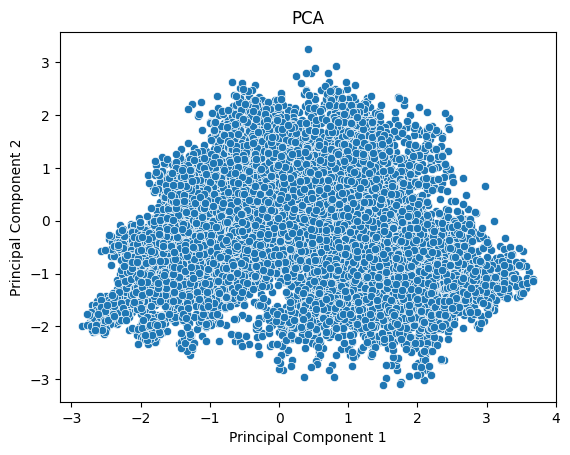

In [57]:
sns.scatterplot(x=transformed_data[:, 0], y=transformed_data[:, 1])
plt.title('PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

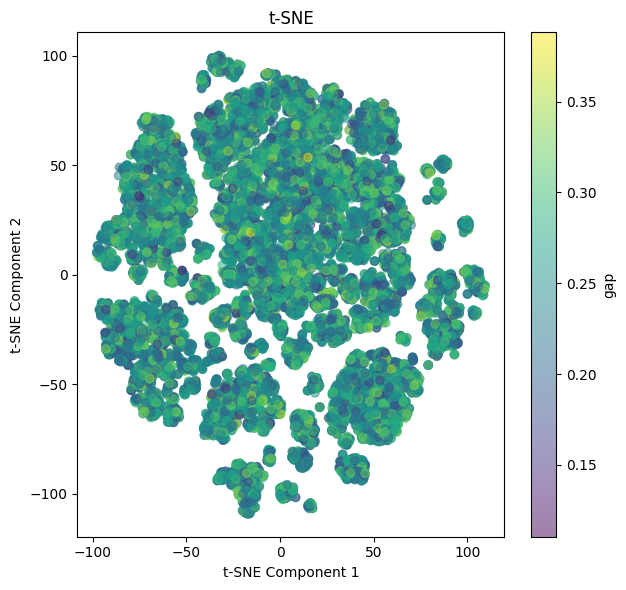

In [51]:
# Получение значения из столбца 'gap' как целевой переменной y
y = transformed_df['gap'].values
X = New_data2_normalized
# Применение t-SNE
tsne = TSNE(n_components=2)
tsne_result = tsne.fit_transform(X)

# Создаем новое окно графика
plt.figure(figsize=(12, 6))

# График для t-SNE
plt.subplot(1, 2, 2)
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=y, cmap='viridis', alpha=0.5)
plt.title('t-SNE')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.colorbar(label='gap')

# Показываем графики
plt.tight_layout()
plt.show()

In [58]:
transformed_df.to_csv('/content/drive/MyDrive/Colab_Notebooks/Alghoritms_and_Data/transformed_df.csv')